In [7]:
# Install CatBoost (if not already installed)
!pip install catboost -q

In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import time

print("✓ All libraries imported.")

✓ All libraries imported.


## Section 0 — Dataset Overview

| Property | Value |
|---|---|
| Domain | Agriculture / Fertilizer Recommendation |
| Shape | 3100 rows × 44 feature columns |
| Target | `Fertilizer` — 10 classes (Label-Encoded 0–9) |
| Numeric features (scaled) | `Temperature`, `Moisture`, `Rainfall`, `PH`, `Nitrogen`, `Phosphorous`, `Potassium`, `Carbon` |
| Categorical features (OHE, not scaled) | `Soil` (5 cols) + `Crop` (31 cols) |

In [9]:
# =============================================================================
# SECTION 0 — LOAD DATA & LABEL ENCODER
# =============================================================================

DATA_PATH = '/content/final_processed_data.csv'
LE_PATH   = '/content/label_encoder_fertilizer.pkl'

df = pd.read_csv(DATA_PATH)

# Separate features and target
X = df.drop(columns=['target_fertilizer'])
y = df['target_fertilizer'].values                    # 1-D integer array (0–9)

# Class mapping (source of truth — no LabelEncoder needed for prediction mapping)
CLASS_MAP = {
    0: 'Balanced NPK Fertilizer',
    1: 'Compost',
    2: 'DAP',
    3: 'General Purpose Fertilizer',
    4: 'Gypsum',
    5: 'Lime',
    6: 'Muriate of Potash',
    7: 'Organic Fertilizer',
    8: 'Urea',
    9: 'Water Retaining Fertilizer',
}

# Load LabelEncoder — try joblib first (sklearn's recommended format),
# fall back to pickle, and gracefully degrade if both fail.
import joblib
le_fert = None
try:
    le_fert = joblib.load(LE_PATH)
    print("✓ LabelEncoder loaded via joblib.")
except Exception:
    try:
        with open(LE_PATH, 'rb') as f:
            le_fert = pickle.load(f)
        print("✓ LabelEncoder loaded via pickle.")
    except Exception as e:
        print(f"⚠ Could not load LabelEncoder ({e}).")
        print("  CLASS_MAP will be used for prediction mapping — no functionality lost.")

# Helper: always works regardless of whether le_fert loaded
def decode_predictions(int_preds):
    """Map integer predictions → fertilizer name strings."""
    if le_fert is not None:
        return le_fert.inverse_transform(int_preds)
    return np.array([CLASS_MAP[i] for i in int_preds])

# Verify shapes
assert X.shape == (3100, 44), f"Unexpected X shape: {X.shape}  (expected (3100, 44))"
assert y.shape == (3100,),    f"Unexpected y shape: {y.shape}  (expected (3100,))"
assert len(np.unique(y)) == 10, f"Expected 10 Fertilizer classes, found {len(np.unique(y))}"

print(f"\nLoaded  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Fertilizer classes : {len(np.unique(y))}")
print()
print("Class distribution:")
for cls_id, cnt in zip(*np.unique(y, return_counts=True)):
    print(f"  {cls_id:2d}  {CLASS_MAP[cls_id]:<30s}  n={cnt}")

✓ LabelEncoder loaded via joblib.

Loaded  : 3100 rows × 45 columns
X shape : (3100, 44)
y shape : (3100,)
Fertilizer classes : 10

Class distribution:
   0  Balanced NPK Fertilizer         n=157
   1  Compost                         n=375
   2  DAP                             n=1054
   3  General Purpose Fertilizer      n=31
   4  Gypsum                          n=52
   5  Lime                            n=181
   6  Muriate of Potash               n=326
   7  Organic Fertilizer              n=95
   8  Urea                            n=154
   9  Water Retaining Fertilizer      n=675


In [10]:
# =============================================================================
# SECTION 1 — TRAIN / TEST SPLIT
# =============================================================================

RANDOM_STATE = 42
TEST_SIZE    = 0.2

# Column names for the 8 numeric features (must be first 8 cols of X)
NUMERIC_COLS = ['Temperature', 'Moisture', 'Rainfall', 'PH',
                'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y            # stratify on Fertilizer target
)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f"Train : X={X_train.shape}, y={y_train.shape}")
print(f"Test  : X={X_test.shape},  y={y_test.shape}")
print("✓ Stratified split complete.")

Train : X=(2480, 44), y=(2480,)
Test  : X=(620, 44),  y=(620,)
✓ Stratified split complete.


In [11]:
# =============================================================================
# SECTION 2 — SELECTIVE SCALING
# Scale ONLY the 8 numeric columns; leave OHE columns (Soil + Crop) untouched.
# Used for distance/kernel-based models: SVM.
# Tree-based models (RF, XGB, GB, Ada, CatBoost) receive raw X values.
# =============================================================================

scaler = StandardScaler()

def scale_numeric_only(X_df, fit=False):
    """Returns a numpy array with numeric cols scaled, OHE cols unchanged."""
    X_copy = X_df.copy()
    if fit:
        X_copy[NUMERIC_COLS] = scaler.fit_transform(X_copy[NUMERIC_COLS])
    else:
        X_copy[NUMERIC_COLS] = scaler.transform(X_copy[NUMERIC_COLS])
    return X_copy.values

X_train_sc = scale_numeric_only(X_train, fit=True)   # fit on train, transform
X_test_sc  = scale_numeric_only(X_test,  fit=False)  # transform test only

print(f"Scaled array shapes — train: {X_train_sc.shape}, test: {X_test_sc.shape}")
print(f"Numeric cols scaled : {NUMERIC_COLS}")
print(f"OHE cols (untouched): {X_train.shape[1] - len(NUMERIC_COLS)} columns")

Scaled array shapes — train: (2480, 44), test: (620, 44)
Numeric cols scaled : ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']
OHE cols (untouched): 36 columns


In [18]:
# =============================================================================
# SECTION 3 — METRIC HELPER
# =============================================================================

os.makedirs("output", exist_ok=True)

def evaluate_classifier(model, X_tr, y_tr, X_te, y_te,
                         model_name, cv_folds=5, verbose=True):
    """Fit model, evaluate on test set, run CV, save confusion matrix."""
    # ── Train ────────────────────────────────────────────────────────────────
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    # ── Predict ──────────────────────────────────────────────────────────────
    y_pred = model.predict(X_te)
    y_pred = np.asarray(y_pred).flatten()  # Guarantee 1D array of scalars

    # ── Metrics ──────────────────────────────────────────────────────────────
    acc      = accuracy_score(y_te, y_pred)
    f1_mac   = f1_score(y_te, y_pred, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    prec_mac = precision_score(y_te, y_pred, average='macro',    zero_division=0)
    prec_wt  = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec_mac  = recall_score(y_te, y_pred, average='macro',    zero_division=0)
    rec_wt   = recall_score(y_te, y_pred, average='weighted', zero_division=0)

    # ── Cross-validation (macro F1 on training data) ─────────────────────────
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv,
                                 scoring='f1_macro', n_jobs=-1)
    cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

    # ── AUC (OvR, macro) ─────────────────────────────────────────────────────
    auc = np.nan
    if hasattr(model, 'predict_proba'):
        try:
            y_prob = model.predict_proba(X_te)
            auc = roc_auc_score(y_te, y_prob,
                                multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan

    # ── Confusion matrix plot (labels = fertilizer names) ────────────────────
    display_labels = [CLASS_MAP[i] for i in sorted(np.unique(y_te))]
    fig, ax = plt.subplots(figsize=(14, 11))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, ax=ax, colorbar=False,
        display_labels=display_labels
    )
    ax.set_title(f"{model_name} — Fertilizer (10 classes)")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"output/cm_{model_name}_Fertilizer.png", dpi=120, bbox_inches='tight')
    plt.close()

    # ── Named prediction sample ───────────────────────────────────────────────
    pred_names = [CLASS_MAP[p] for p in y_pred]

    # ── Result dict ──────────────────────────────────────────────────────────
    result = {
        'Model':         model_name,
        'Accuracy':      round(acc,      4),
        'Precision_Mac': round(prec_mac, 4),
        'Precision_Wt':  round(prec_wt,  4),
        'Recall_Mac':    round(rec_mac,  4),
        'Recall_Wt':     round(rec_wt,   4),
        'F1_Macro':      round(f1_mac,   4),
        'F1_Weighted':   round(f1_wt,    4),
        'AUC_OVR':       round(auc, 4) if not np.isnan(auc) else 'N/A',
        'CV_F1_Mean':    round(cv_mean,  4),
        'CV_F1_Std':     round(cv_std,   4),
        'Train_Time_s':  round(elapsed,  2),
    }

    if verbose:
        auc_display = f"{auc:.4f}" if not np.isnan(auc) else "N/A"

        print(f"\n{'='*58}")
        print(f"  {model_name}")
        print(f"  Accuracy        : {acc:.4f}")
        print(f"  Precision (mac) : {prec_mac:.4f}  | Weighted: {prec_wt:.4f}")
        print(f"  Recall    (mac) : {rec_mac:.4f}  | Weighted: {rec_wt:.4f}")
        print(f"  F1        (mac) : {f1_mac:.4f}  | Weighted: {f1_wt:.4f}")
        print(f"  AUC (OVR macro) : {auc_display}")
        print(f"  CV F1 (5-fold)  : {cv_mean:.4f} ± {cv_std:.4f}")
        print(f"  Train time      : {elapsed:.2f}s")

    return result, model, y_pred, pred_names

all_results = []
print("✓ evaluate_classifier() defined.")

✓ evaluate_classifier() defined.


In [19]:
# =============================================================================
# SECTION 4 — MODEL DEFINITIONS  (single target: Fertilizer only)
# =============================================================================

N_CLASSES = len(np.unique(y_train))   # 10

# ── 4A. Random Forest ────────────────────────────────────────────────────────
# Tree-based: receives raw (unscaled) X
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ── 4B. SVM (RBF kernel) ─────────────────────────────────────────────────────
# Distance-based: receives selectively scaled X
svm = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,      # required for AUC
    random_state=RANDOM_STATE
)

# ── 4C. XGBoost ──────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    num_class=N_CLASSES,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ── 4D. AdaBoost ─────────────────────────────────────────────────────────────
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    algorithm='SAMME'
)

# ── 4E. Gradient Boosting ─────────────────────────────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=RANDOM_STATE
)

# ── 4F. CatBoost ──────────────────────────────────────────────────────────────
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=RANDOM_STATE,
    verbose=0
)

print(f"✓ All base models defined for Fertilizer ({N_CLASSES} classes).")

✓ All base models defined for Fertilizer (10 classes).


In [20]:
# =============================================================================
# SECTION 5 — TRAIN & EVALUATE BASE MODELS
#
# Scaling rule:
#   SVM_RBF → selectively scaled X (numeric cols only)
#   All others → raw X (tree-based; scaling irrelevant)
# =============================================================================

# Map model name → (model object, use_scaled_X?)
base_models = {
    'RandomForest':     (rf,  False),
    'SVM_RBF':          (svm, True),
    'XGBoost':          (xgb, False),
    'AdaBoost':         (ada, False),
    'GradientBoosting': (gb,  False),
    'CatBoost':         (cat, False),
}

fitted_models = {}   # store fitted models for later inspection / stacking

for model_name, (model, use_scaled) in base_models.items():
    X_tr_in = X_train_sc       if use_scaled else X_train.values
    X_te_in = X_test_sc        if use_scaled else X_test.values

    res, fitted_m, y_pred, pred_names = evaluate_classifier(
        model, X_tr_in, y_train, X_te_in, y_test,
        model_name=model_name
    )
    all_results.append(res)
    fitted_models[model_name] = fitted_m

print("\n✓ All base models trained and evaluated.")


  RandomForest
  Accuracy        : 0.9290
  Precision (mac) : 0.8982  | Weighted: 0.9359
  Recall    (mac) : 0.8877  | Weighted: 0.9290
  F1        (mac) : 0.8660  | Weighted: 0.9263
  AUC (OVR macro) : 0.9873
  CV F1 (5-fold)  : 0.8987 ± 0.0093
  Train time      : 1.88s

  SVM_RBF
  Accuracy        : 0.7581
  Precision (mac) : 0.7229  | Weighted: 0.7616
  Recall    (mac) : 0.5894  | Weighted: 0.7581
  F1        (mac) : 0.6196  | Weighted: 0.7405
  AUC (OVR macro) : 0.9681
  CV F1 (5-fold)  : 0.6322 ± 0.0370
  Train time      : 1.85s

  XGBoost
  Accuracy        : 0.9387
  Precision (mac) : 0.8930  | Weighted: 0.9437
  Recall    (mac) : 0.9459  | Weighted: 0.9387
  F1        (mac) : 0.9137  | Weighted: 0.9388
  AUC (OVR macro) : 0.9928
  CV F1 (5-fold)  : 0.9404 ± 0.0210
  Train time      : 3.32s

  AdaBoost
  Accuracy        : 0.5677
  Precision (mac) : 0.2195  | Weighted: 0.4903
  Recall    (mac) : 0.2241  | Weighted: 0.5677
  F1        (mac) : 0.1912  | Weighted: 0.4791
  AUC (OVR 

In [21]:
# =============================================================================
# SECTION 6 — RESULTS SUMMARY
# =============================================================================

results_df = pd.DataFrame(all_results).sort_values('F1_Macro', ascending=False).reset_index(drop=True)

SUMMARY_COLS = [
    'Model', 'Accuracy',
    'Precision_Mac', 'Precision_Wt',
    'Recall_Mac',    'Recall_Wt',
    'F1_Macro',      'F1_Weighted',
    'AUC_OVR',
    'CV_F1_Mean', 'CV_F1_Std',
    'Train_Time_s'
]

print("="*100)
print("BASE MODEL RESULTS — Fertilizer (10 classes)")
print("Note: Dataset may be imbalanced → prioritise Macro metrics over Weighted.")
print("="*100)
print(results_df[SUMMARY_COLS].to_string(index=False))

best = results_df.iloc[0]
print(f"\n★ Best model : {best['Model']}")
print(f"  F1_Macro   : {best['F1_Macro']}")
print(f"  CV F1      : {best['CV_F1_Mean']} ± {best['CV_F1_Std']}")

# Save
results_df.to_csv('output/model_comparison_results.csv', index=False)
print("\n✓ Results saved → output/model_comparison_results.csv")

BASE MODEL RESULTS — Fertilizer (10 classes)
Note: Dataset may be imbalanced → prioritise Macro metrics over Weighted.
           Model  Accuracy  Precision_Mac  Precision_Wt  Recall_Mac  Recall_Wt  F1_Macro  F1_Weighted  AUC_OVR  CV_F1_Mean  CV_F1_Std  Train_Time_s
         XGBoost    0.9387         0.8930        0.9437      0.9459     0.9387    0.9137       0.9388   0.9928      0.9404     0.0210          3.32
        CatBoost    0.9355         0.8963        0.9389      0.9178     0.9355    0.9054       0.9352   0.9913      0.9400     0.0203          9.54
GradientBoosting    0.9387         0.8883        0.9410      0.9040     0.9387    0.8947       0.9386   0.9930      0.9273     0.0172         18.36
    RandomForest    0.9290         0.8982        0.9359      0.8877     0.9290    0.8660       0.9263   0.9873      0.8987     0.0093          1.88
         SVM_RBF    0.7581         0.7229        0.7616      0.5894     0.7581    0.6196       0.7405   0.9681      0.6322     0.0370        

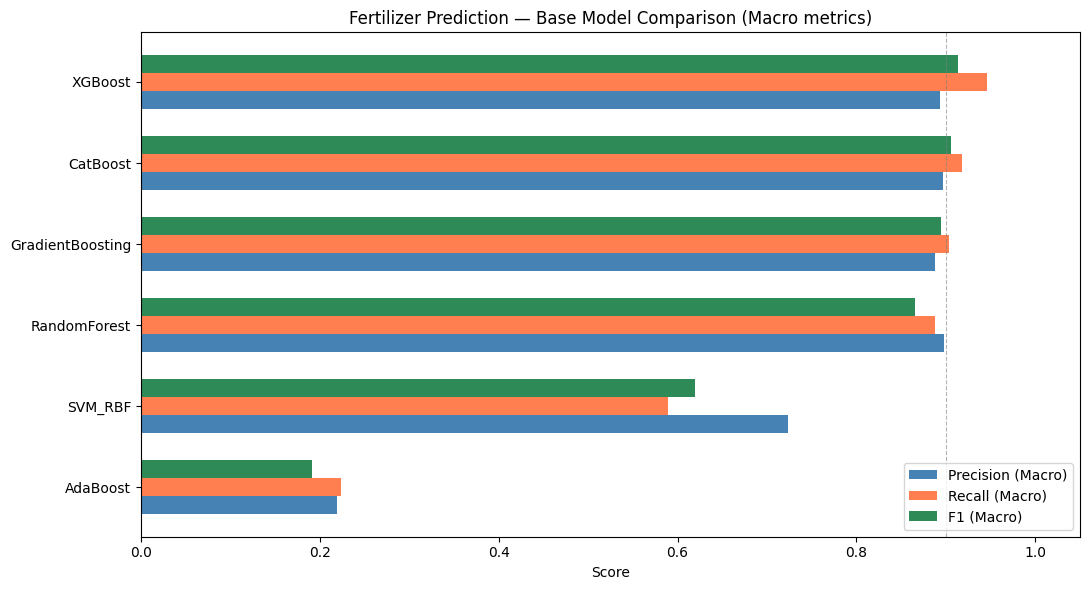

✓ Bar chart saved → output/model_comparison_bar.png


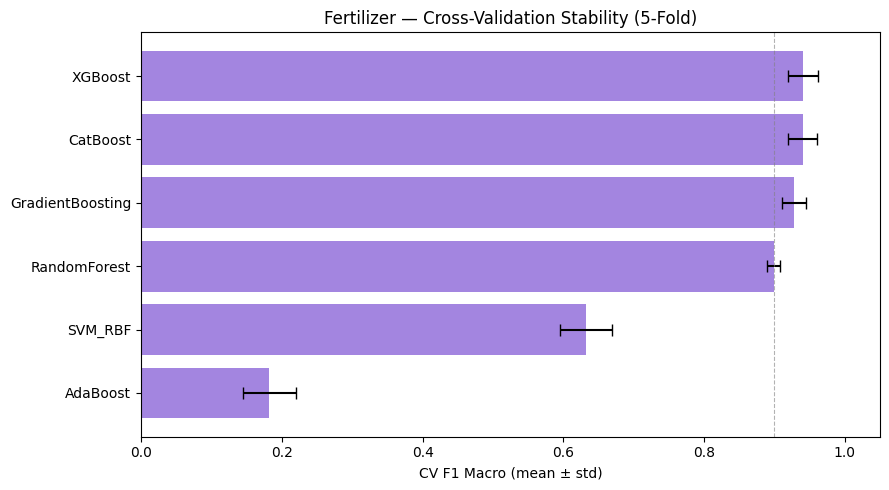

✓ CV stability chart saved → output/cv_stability.png


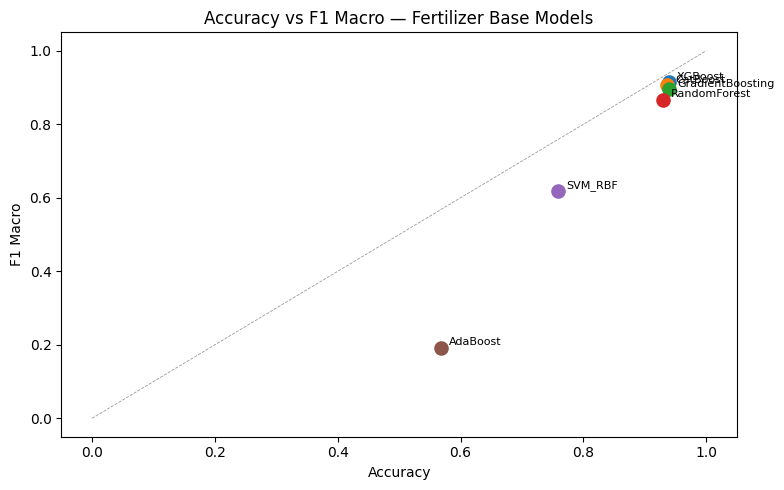

✓ Accuracy vs F1 scatter saved → output/acc_vs_f1.png


In [22]:
# =============================================================================
# SECTION 7 — VISUALISATIONS
# =============================================================================

# ── 7A. Precision / Recall / F1 bar chart ────────────────────────────────────
plot_df = results_df.sort_values('F1_Macro')  # ascending so best is at top
models  = plot_df['Model'].values
x       = np.arange(len(models))
width   = 0.22

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(x - width,  plot_df['Precision_Mac'], width, label='Precision (Macro)', color='steelblue')
ax.barh(x,          plot_df['Recall_Mac'],    width, label='Recall (Macro)',    color='coral')
ax.barh(x + width,  plot_df['F1_Macro'],      width, label='F1 (Macro)',        color='seagreen')
ax.set_yticks(x)
ax.set_yticklabels(models)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Score')
ax.set_title('Fertilizer Prediction — Base Model Comparison (Macro metrics)')
ax.legend(loc='lower right')
ax.axvline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig('output/model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Bar chart saved → output/model_comparison_bar.png")

# ── 7B. CV stability chart ────────────────────────────────────────────────────
cv_df = results_df.sort_values('CV_F1_Mean')

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    cv_df['Model'], cv_df['CV_F1_Mean'],
    xerr=cv_df['CV_F1_Std'],
    color='mediumpurple', ecolor='black', capsize=4, alpha=0.85
)
ax.set_xlim(0, 1.05)
ax.set_xlabel('CV F1 Macro (mean ± std)')
ax.set_title('Fertilizer — Cross-Validation Stability (5-Fold)')
ax.axvline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig('output/cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ CV stability chart saved → output/cv_stability.png")

# ── 7C. Accuracy vs F1_Macro scatter ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in results_df.iterrows():
    ax.scatter(row['Accuracy'], row['F1_Macro'], s=90, zorder=3)
    ax.annotate(row['Model'], (row['Accuracy'], row['F1_Macro']),
                textcoords='offset points', xytext=(6, 2), fontsize=8)
ax.set_xlabel('Accuracy')
ax.set_ylabel('F1 Macro')
ax.set_title('Accuracy vs F1 Macro — Fertilizer Base Models')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.6, alpha=0.4)  # diagonal reference
plt.tight_layout()
plt.savefig('output/acc_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Accuracy vs F1 scatter saved → output/acc_vs_f1.png")

In [23]:
# =============================================================================
# SECTION 8 — SAMPLE PREDICTIONS WITH NAMED LABELS
# Uses the best model to demonstrate integer → fertilizer name mapping.
# =============================================================================

best_model_name = results_df.iloc[0]['Model']
best_model_obj  = fitted_models[best_model_name]
use_scaled      = base_models[best_model_name][1]

X_te_in = X_test_sc if use_scaled else X_test.values

sample_idx  = np.random.default_rng(42).integers(0, len(X_test), size=10)
y_pred_int  = best_model_obj.predict(X_te_in[sample_idx])
y_true_int  = y_test[sample_idx]

sample_df = pd.DataFrame({
    'True_Label':      y_true_int,
    'True_Fertilizer': [CLASS_MAP[i] for i in y_true_int],
    'Pred_Label':      y_pred_int,
    'Pred_Fertilizer': [CLASS_MAP[i] for i in y_pred_int],
    'Correct':         y_true_int == y_pred_int,
})

print(f"Sample predictions from best model: {best_model_name}")
print(sample_df.to_string(index=False))

Sample predictions from best model: XGBoost
 True_Label            True_Fertilizer  Pred_Label            Pred_Fertilizer  Correct
          9 Water Retaining Fertilizer           9 Water Retaining Fertilizer     True
          2                        DAP           2                        DAP     True
          2                        DAP           2                        DAP     True
          1                    Compost           9 Water Retaining Fertilizer    False
          2                        DAP           2                        DAP     True
          3 General Purpose Fertilizer           3 General Purpose Fertilizer     True
          1                    Compost           1                    Compost     True
          2                        DAP           2                        DAP     True
          2                        DAP           2                        DAP     True
          2                        DAP           2                        DAP     True